# Modelling v1 — EKF + Newton Raphson vs Linear Regression
Implementasi sesuai paper: Fahmy et al. (2025)

Pipeline:
1. EKF berjalan per-cycle tracking degradasi kapasitas (QDischarge)
2. Newton Raphson mencari cycle ke berapa kapasitas menyentuh EOL threshold
3. Dibandingkan dengan Linear Regression ElasticNet sebagai baseline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
from config_v1 import (
    OUTPUT_DIR, EKF_P0, EKF_R, EKF_Q,
    BATTERY_Q_NOMINAL, BATTERY_RO,
    NR_TOL, NR_MAX_ITER
)

EOL_THRESHOLD = 0.88  # 80% of 1.1 Ah

## 1. Load Preprocessed Data

In [3]:
with open(os.path.join(OUTPUT_DIR, 'preprocessed_v1.pkl'), 'rb') as f:
    data = pickle.load(f)

train_cells = data['train']
val_cells   = data['val']
test_cells  = data['test']

print(f'Train: {len(train_cells)} | Val: {len(val_cells)} | Test: {len(test_cells)}')

Train: 41 | Val: 43 | Test: 40


## 2. EKF — Tracking Degradasi Kapasitas per Cycle

EKF berjalan di level cycle (bukan timestep).
State: x = [Q_k, dQ_k] = [kapasitas cycle k, laju degradasi]
Measurement: QDischarge dari summary data
Output: smoothed capacity curve per cell

Parameter dari Table 2 paper: P0=[2,0], R=0.01, Q=[0.8,0.2]

In [4]:
def run_ekf_capacity(Q_discharge, P0, Rw, Rv):
    n = len(Q_discharge)

    # State: x = [Q, dQ] — capacity and degradation rate
    x = np.array([Q_discharge[0], 0.0])
    P = np.diag(P0)

    # Process model: Q_{k+1} = Q_k + dQ_k, dQ_{k+1} = dQ_k
    A = np.array([[1, 1],
                  [0, 1]])
    H = np.array([[1, 0]])
    Rw_mat = np.diag(Rw)

    Q_smoothed = []

    for k in range(n):
        # Predict
        x_pred = A @ x
        P_pred = A @ P @ A.T + Rw_mat

        # Update
        S = H @ P_pred @ H.T + Rv
        K = P_pred @ H.T / S[0, 0]
        innov = Q_discharge[k] - (H @ x_pred)[0]
        x = x_pred + K.flatten() * innov
        P = (np.eye(2) - K @ H) @ P_pred

        Q_smoothed.append(x[0])

    return np.array(Q_smoothed)

## 3. Newton Raphson — Prediksi Cycle EOL

Setelah EKF menghasilkan smoothed capacity curve,
fit model degradasi linear ke trend tersebut.
NR mencari root dari f(x) = Q_model(x) - EOL_threshold = 0
dimana x adalah cycle number → predicted cycle life.

In [5]:
def fit_degradation_model(Q_smoothed):
    n = len(Q_smoothed)
    cycles = np.arange(1, n + 1, dtype=float)
    # Fit polynomial degree 2 untuk capture nonlinear degradation
    coeffs = np.polyfit(cycles, Q_smoothed, deg=2)
    return coeffs


def newton_raphson_eol(coeffs, eol_threshold, x0, tol=1e-6, max_iter=100):
    # f(x) = p(x) - eol_threshold
    # p(x) = a*x^2 + b*x + c
    a, b, c = coeffs

    def f(x):  return a*x**2 + b*x + c - eol_threshold
    def df(x): return 2*a*x + b

    x = x0
    for _ in range(max_iter):
        fx  = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-12:
            break
        x_new = x - fx / dfx
        if abs(x_new - x) < tol:
            return max(x_new, 1.0)
        x = x_new
    return max(x, 1.0)


def predict_cycle_life(cell, P0, Rw, Rv, eol_threshold, tol, max_iter):
    Q = cell['summary']['QDischarge']

    if len(Q) < 10:
        return np.nan

    Q_smoothed = run_ekf_capacity(Q, P0, Rw, Rv)
    coeffs = fit_degradation_model(Q_smoothed)

    # Initial guess: extrapolate linear trend
    a, b, c = coeffs
    # Use last smoothed value slope as initial guess direction
    x0 = len(Q) * 1.5  # start search beyond observed cycles

    predicted = newton_raphson_eol(coeffs, eol_threshold, x0, tol, max_iter)
    return predicted

## 4. Run EKF + NR pada Test Set

In [6]:
P0_val = EKF_P0
Rw_val = EKF_Q
Rv_val = np.array([[EKF_R]])

actual_ekfnr    = []
predicted_ekfnr = []

for i, cell in enumerate(test_cells):
    pred = predict_cycle_life(
        cell, P0_val, Rw_val, Rv_val,
        EOL_THRESHOLD, NR_TOL, NR_MAX_ITER
    )
    actual_ekfnr.append(cell['cycle_life'])
    predicted_ekfnr.append(pred)
    print(f'Cell {i+1:02d} | Actual: {cell["cycle_life"]:6.0f} | Predicted: {pred:8.2f}')

actual_ekfnr    = np.array(actual_ekfnr)
predicted_ekfnr = np.array(predicted_ekfnr)

Cell 01 | Actual:    857 | Predicted:   926.10
Cell 02 | Actual:    617 | Predicted:   664.07
Cell 03 | Actual:    471 | Predicted:   484.23
Cell 04 | Actual:   1146 | Predicted:  1245.54
Cell 05 | Actual:    636 | Predicted:   709.62
Cell 06 | Actual:    713 | Predicted:   739.00
Cell 07 | Actual:    935 | Predicted:  1065.11
Cell 08 | Actual:    813 | Predicted:   927.91
Cell 09 | Actual:    982 | Predicted:   994.05
Cell 10 | Actual:    444 | Predicted:   452.71
Cell 11 | Actual:   1267 | Predicted:  1367.39
Cell 12 | Actual:    300 | Predicted:   296.34
Cell 13 | Actual:   1115 | Predicted:  1242.36
Cell 14 | Actual:    209 | Predicted:   210.55
Cell 15 | Actual:   1046 | Predicted:  1189.85
Cell 16 | Actual:    520 | Predicted:   541.56
Cell 17 | Actual:   1155 | Predicted:  1254.37
Cell 18 | Actual:    487 | Predicted:   504.37
Cell 19 | Actual:   1051 | Predicted:  1137.06
Cell 20 | Actual:    458 | Predicted:   462.88
Cell 21 | Actual:    457 | Predicted:   475.25
Cell 22 | Act

## 5. Sanity Check — Plot EKF Smoothing pada 1 Sel

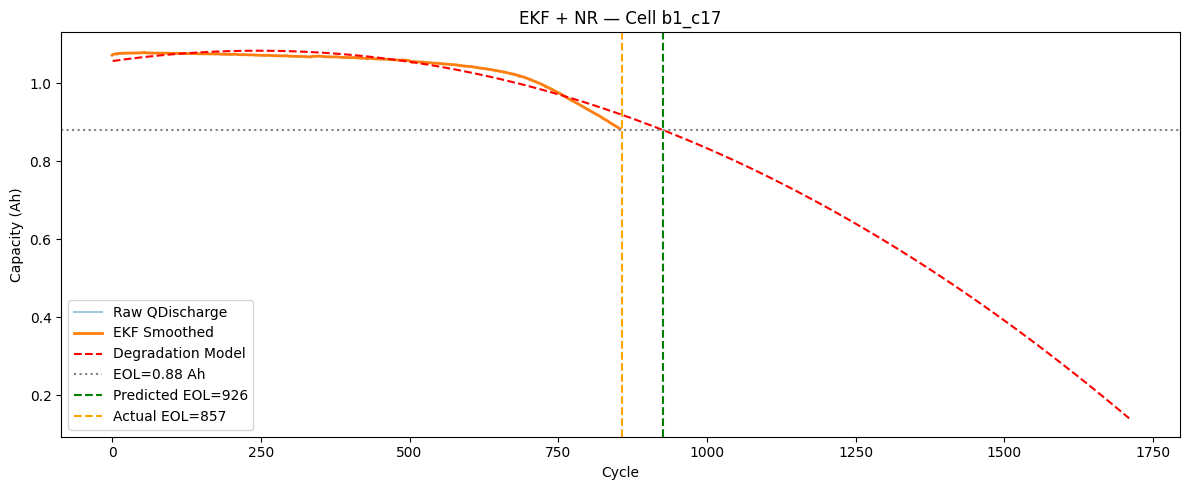

In [7]:
sample = test_cells[0]
Q_raw  = sample['summary']['QDischarge']
Q_smooth = run_ekf_capacity(Q_raw, P0_val, Rw_val, Rv_val)
coeffs   = fit_degradation_model(Q_smooth)

x_range = np.linspace(1, len(Q_raw) * 2, 500)
Q_model = np.polyval(coeffs, x_range)

pred_life = predict_cycle_life(sample, P0_val, Rw_val, Rv_val, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER)

plt.figure(figsize=(12, 5))
plt.plot(Q_raw,    alpha=0.4, label='Raw QDischarge')
plt.plot(Q_smooth, label='EKF Smoothed', linewidth=2)
plt.plot(x_range, Q_model, 'r--', label='Degradation Model')
plt.axhline(EOL_THRESHOLD, color='gray', linestyle=':', label=f'EOL={EOL_THRESHOLD} Ah')
plt.axvline(pred_life, color='green', linestyle='--', label=f'Predicted EOL={pred_life:.0f}')
plt.axvline(sample['cycle_life'], color='orange', linestyle='--', label=f'Actual EOL={sample["cycle_life"]:.0f}')
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.title(f'EKF + NR — Cell {sample["cell_id"]}')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Linear Regression Baseline (Elastic Net)

In [8]:
def extract_features(cells):
    feats, targets = [], []
    for cell in cells:
        q  = cell['summary']['QDischarge']
        ir = cell['summary']['IR']
        if len(q) < 100:
            continue
        feats.append([
            np.mean(q[1:101]),
            np.min(q[1:101]),
            np.var(q[1:101]),
            q[99] - q[9],
            np.mean(ir[1:101]),
            np.log(np.var(q[1:101]) + 1e-10),
        ])
        targets.append(cell['cycle_life'])
    return np.array(feats), np.array(targets)


X_train, y_train = extract_features(train_cells)
X_val,   y_val   = extract_features(val_cells)
X_test,  y_test  = extract_features(test_cells)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

lr_model = ElasticNetCV(cv=5, max_iter=10000, random_state=42)
lr_model.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))

predicted_lr = lr_model.predict(X_test)
actual_lr    = y_test
print(f'ElasticNet alpha={lr_model.alpha_:.4f}, l1_ratio={lr_model.l1_ratio_:.4f}')

ElasticNet alpha=3.1220, l1_ratio=0.5000


## 7. Evaluasi — RMSE & Average Percentage Error

In [9]:
def rmse(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.sqrt(np.mean((actual[mask] - predicted[mask]) ** 2))

def avg_pct_error(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.mean(np.abs(actual[mask] - predicted[mask]) / actual[mask]) * 100


rmse_ekfnr = rmse(actual_ekfnr, predicted_ekfnr)
ape_ekfnr  = avg_pct_error(actual_ekfnr, predicted_ekfnr)
rmse_lr    = rmse(actual_lr, predicted_lr)
ape_lr     = avg_pct_error(actual_lr, predicted_lr)

print('=' * 57)
print(f'{"Method":<32} {"RMSE":>10} {"Avg%Err":>10}')
print('=' * 57)
print(f'{"EKF + Newton Raphson":<32} {rmse_ekfnr:>10.4f} {ape_ekfnr:>9.4f}%')
print(f'{"Linear Regression (ElasticNet)":<32} {rmse_lr:>10.4f} {ape_lr:>9.4f}%')
print('=' * 57)
print(f'\nPaper target EKF+NR  → RMSE: 10.93  | Avg%Err: 3.26%')
print(f'Paper target LinReg  → RMSE: 211.6  | Avg%Err: 9.98%')

Method                                 RMSE    Avg%Err
EKF + Newton Raphson               423.2679   14.4617%
Linear Regression (ElasticNet)     227.7467   36.7859%

Paper target EKF+NR  → RMSE: 10.93  | Avg%Err: 3.26%
Paper target LinReg  → RMSE: 211.6  | Avg%Err: 9.98%


## 8. Visualisasi — Actual vs Predicted (Fig. 4 & 5 paper)

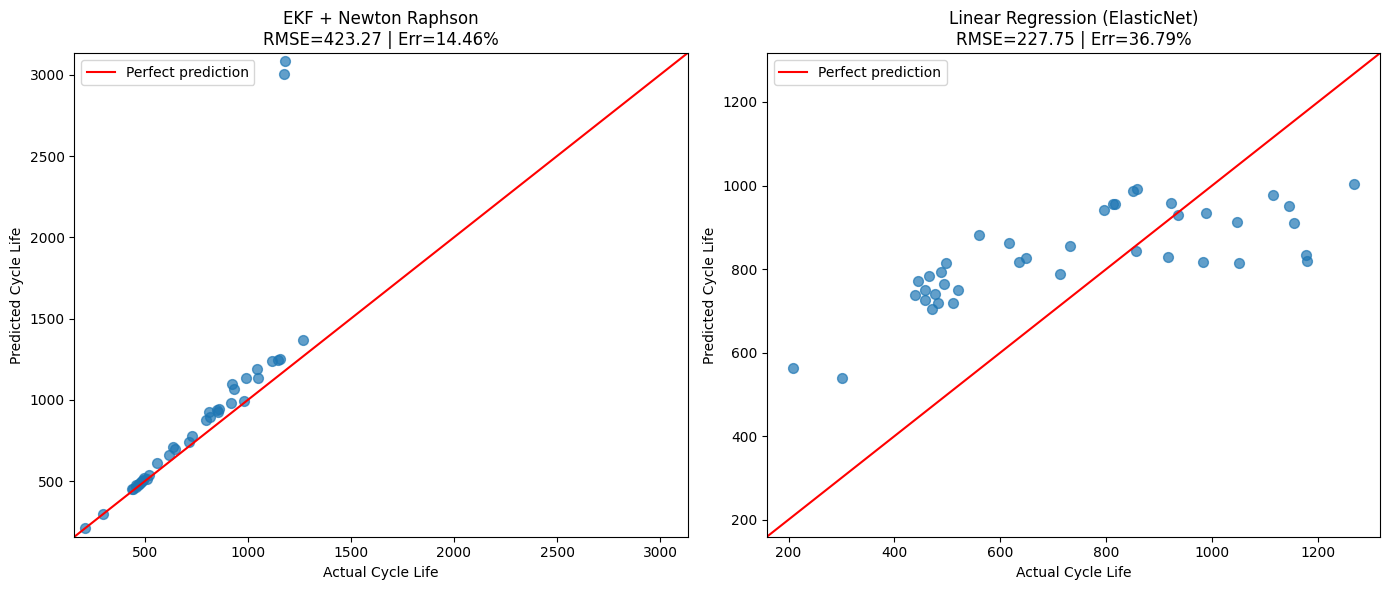

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pairs = [
    (actual_ekfnr, predicted_ekfnr, 'EKF + Newton Raphson'),
    (actual_lr,    predicted_lr,    'Linear Regression (ElasticNet)'),
]

for ax, (actual, predicted, title) in zip(axes, pairs):
    mask = ~np.isnan(predicted)
    a, p = actual[mask], predicted[mask]
    lims = [min(a.min(), p.min()) - 50, max(a.max(), p.max()) + 50]
    ax.plot(lims, lims, 'r-', linewidth=1.5, label='Perfect prediction')
    ax.scatter(a, p, alpha=0.7, s=50)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual Cycle Life')
    ax.set_ylabel('Predicted Cycle Life')
    ax.set_title(f'{title}\nRMSE={rmse(actual, predicted):.2f} | Err={avg_pct_error(actual, predicted):.2f}%')
    ax.legend()

plt.tight_layout()
os.makedirs(os.path.join(OUTPUT_DIR, 'figures'), exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'actual_vs_predicted_v1.png'), dpi=150)
plt.show()

## 9. Visualisasi — Per Cell (Fig. 6 paper)

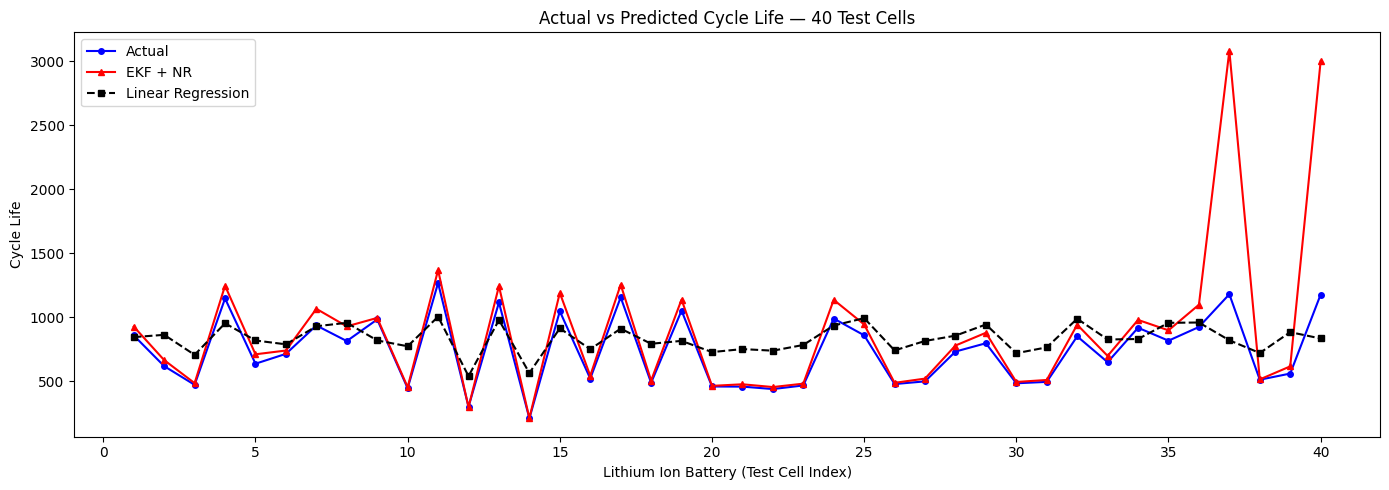

In [11]:
x_idx = np.arange(1, len(actual_ekfnr) + 1)

plt.figure(figsize=(14, 5))
plt.plot(x_idx, actual_ekfnr,    'b-o',  markersize=4, label='Actual')
plt.plot(x_idx, predicted_ekfnr, 'r-^',  markersize=4, label='EKF + NR')
plt.plot(x_idx, predicted_lr,    'k--s', markersize=4, label='Linear Regression')
plt.xlabel('Lithium Ion Battery (Test Cell Index)')
plt.ylabel('Cycle Life')
plt.title('Actual vs Predicted Cycle Life — 40 Test Cells')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', 'per_cell_comparison_v1.png'), dpi=150)
plt.show()

## 10. Simpan Hasil

In [12]:
results = {
    'ekf_nr': {
        'actual':        actual_ekfnr.tolist(),
        'predicted':     predicted_ekfnr.tolist(),
        'rmse':          rmse_ekfnr,
        'avg_pct_error': ape_ekfnr,
    },
    'linear_regression': {
        'actual':        actual_lr.tolist(),
        'predicted':     predicted_lr.tolist(),
        'rmse':          rmse_lr,
        'avg_pct_error': ape_lr,
    }
}

os.makedirs(os.path.join(OUTPUT_DIR, 'results'), exist_ok=True)
with open(os.path.join(OUTPUT_DIR, 'results', 'results_v1.pkl'), 'wb') as f:
    pickle.dump(results, f)

print('Results saved.')
print(f'\nFinal Summary:')
print(f'  EKF+NR  → RMSE: {rmse_ekfnr:.4f} | Avg%Err: {ape_ekfnr:.4f}%')
print(f'  LinReg  → RMSE: {rmse_lr:.4f} | Avg%Err: {ape_lr:.4f}%')

Results saved.

Final Summary:
  EKF+NR  → RMSE: 423.2679 | Avg%Err: 14.4617%
  LinReg  → RMSE: 227.7467 | Avg%Err: 36.7859%
